# **Modelo de predição do posicionamento político do eleitor brasileiro**

Projeto final realizado para a disciplina de Ciência de Dados do curso de Ciência da Computação, *Universidade de São Paulo*.

## **Introdução**

Nesta seção será desenvolvido o modelo preditivo para prever o posicionamento político baseado em respostas a determinadas perguntas. O algoritmo utilizado será o ***CatBoost***, que utiliza a técnica de *gradient boosting* em *árvores de decisão* e destaca-se pela sua eficiência em lidar com variáveis categóricas de forma nativa e eficiente. O fato que mais pesa a favor da escolha desse algoritmo é o fato dele tratar variáveis categóricas diretamente, sem ter que utilizar os dados categóricos em forma numérica ou passar por pré-processamento dos dados com o uso de, principalmente, One-Hot Encoding, o que poderia resultar em uma quantidade excessiva de colunas a serem consideradas. Como as variáveis do conjunto de dados em questão são todas categóricas, a escolha é justificada. Mais informações no <a href="https://catboost.ai/" target="_blank" rel="noopener noreferrer">site do CatBoost</a>.

## **1. Importação de bibliotecas e configurações gerais**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from utils import map_df_to_text

## **2. Carregamento dos dados**

In [2]:
df_ml = pd.read_csv(r'..\data\processed\data2024.csv', sep=';')

## **3. Filtrando por colunas importantes**

Baseado na análise estatística realizada na seção **6.3** da análise dos dados, serão consideradas apenas as questões que aparentam ser as mais importantes para a previsão do posicionamento político.

In [3]:
df_ml.drop(columns=['V27', 'V03', 'V02', 'P04', 'VD_REGIAO', 'P50', 'P51'], inplace=True)

## **4. Convertendo para valores textuais**

Como o CatBoost permite trabalhar com valores textuais, essa será a abordagem utilizada para melhorar o entendimento do modelo gerado.

In [4]:
path_excel = r"..\data\raw\panorama_politico_06_2024\DATASEN BR 2024 06 BAROMETRO - DICIONARIO DE DADOS.xlsx"
columns_names = ['empresas_impedir_fnews', 'importancia_controle_fnews', 'petrobras_combustiveis', 'uso_maconha', 'cotas_universidades', 'direito_aborto', 'pena_morte', 'posse_armas', 'confianca_urnas', 'satisfacao_democracia', 'regime_governo', 'religiao', 'escolaridade', 'faixa_etaria', 'posicionamento_politico']

df_ml = map_df_to_text(df_ml, path_excel, columns_names)

## **5. Salvando os dados textuais usados no modelo**

In [5]:
df_ml.to_csv(r'..\data\processed\data_ml2024.csv', sep=';', index=False)

## **6. Treinamento do modelo**

### **6.1. Preparação dos dados e split estratificado**

O conjunto de dados resultante será dividido da seguinte forma: 70% para treino, 15% para validação e 15% para teste, mantendo a proporção do desbalanceamento da variável alvo.

In [6]:
target_col = 'posicionamento_politico'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

cat_features = list(X.columns)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)

print(f"Amostras -> Treino: {len(X_train)} | Validação: {len(X_valid)} | Teste: {len(X_test)}")
print(f"Distribuição classes treino: {y_train.value_counts(normalize=True)}")
print(f"Distribuição classes valid: {y_valid.value_counts(normalize=True)}")
print(f"Distribuição classes teste: {y_test.value_counts(normalize=True)}")

train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

Amostras -> Treino: 8640 | Validação: 1853 | Teste: 1852
Distribuição classes treino: posicionamento_politico
Direita     0.542593
Esquerda    0.264120
Centro      0.193287
Name: proportion, dtype: float64
Distribuição classes valid: posicionamento_politico
Direita     0.542364
Esquerda    0.264436
Centro      0.193200
Name: proportion, dtype: float64
Distribuição classes teste: posicionamento_politico
Direita     0.542657
Esquerda    0.264039
Centro      0.193305
Name: proportion, dtype: float64


### **6.2. Configuração do modelo base e grid de hiperparâmetros**

O modelo base e a grade de parâmetros são ajustados para o tuning de hiperparâmetros. O treinamento será feito com a GPU para melhor velocidade e a principal métrica considerada será o F1-score, tendo em vista que a variável alvo é desbalanceada.

In [7]:
model_base = CatBoostClassifier(
    task_type="GPU",
    devices='0',
    loss_function='MultiClass',
    eval_metric='TotalF1',
    early_stopping_rounds=75,
    bootstrap_type="Bayesian",
    verbose=0,
    random_seed=42
)

grid_params = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 9],
    'iterations': [700, 1200, 1500],
    'random_strength': [1, 3, 5, 7],
    'auto_class_weights': ['Balanced', 'SqrtBalanced'],
    'bagging_temperature': [0.0, 0.5, 1.0],
    'one_hot_max_size': [2, 5, 10],
    'grow_policy': ['SymmetricTree', 'Lossguide']
}

### **6.3. Otimização de hiperparâmetros com randomized search**

In [8]:
print("Iniciando hyperparameter tuning com randomized search e GPU...")

search_results = model_base.randomized_search(
    grid_params,
    X=train_pool,
    cv=5,
    n_iter=30,
    partition_random_seed=42,
    stratified=True,
    refit=False,
    verbose=False,
    plot=False
)

best_params = search_results['params']
print(f"\nMelhores parâmetros encontrados: {best_params}")

Iniciando hyperparameter tuning com randomized search e GPU...
bestTest = 0.584686955
bestIteration = 69
bestTest = 0.578083974
bestIteration = 160
bestTest = 0.5847013298
bestIteration = 42
bestTest = 0.5760601047
bestIteration = 127
bestTest = 0.558559773
bestIteration = 41
bestTest = 0.5694178771
bestIteration = 68
bestTest = 0.5724200405
bestIteration = 239
bestTest = 0.5670762264
bestIteration = 49
bestTest = 0.5838103161
bestIteration = 21
bestTest = 0.5901146419
bestIteration = 217
bestTest = 0.5929972984
bestIteration = 78
bestTest = 0.5785691116
bestIteration = 81
bestTest = 0.5781405472
bestIteration = 132
bestTest = 0.5829539008
bestIteration = 115
bestTest = 0.5839973079
bestIteration = 139
bestTest = 0.5836933684
bestIteration = 36
bestTest = 0.5867861962
bestIteration = 121
bestTest = 0.5728000259
bestIteration = 17
bestTest = 0.5805065732
bestIteration = 102
bestTest = 0.5813660251
bestIteration = 80
bestTest = 0.5798201583
bestIteration = 88
bestTest = 0.5821774766
best

### **6.4. Treinamento do modelo final**

In [9]:
print("\nTreinando modelo final...")

final_model = CatBoostClassifier(
    **best_params,
    task_type="GPU",
    devices='0',
    loss_function='MultiClass',
    eval_metric='TotalF1',
    early_stopping_rounds=75,
    bootstrap_type="Bayesian",
    verbose=100,
    random_seed=42
)

final_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
y_pred = final_model.predict(test_pool).flatten()


Treinando modelo final...
0:	learn: 0.5807229	test: 0.5699480	best: 0.5699480 (0)	total: 13.5ms	remaining: 9.44s
100:	learn: 0.6497395	test: 0.5743454	best: 0.5827547 (85)	total: 1.15s	remaining: 6.82s
bestTest = 0.5827547419
bestIteration = 85
Shrink model to first 86 iterations.


### **6.5. Métricas gerais**

In [10]:
print(classification_report(y_test, y_pred, zero_division=0))
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score Macro: {f1_macro:.4f} | F1-Score Weighted: {f1_weighted:.4f}")

              precision    recall  f1-score   support

      Centro       0.34      0.44      0.38       358
     Direita       0.81      0.67      0.73      1005
    Esquerda       0.57      0.66      0.61       489

    accuracy                           0.62      1852
   macro avg       0.57      0.59      0.57      1852
weighted avg       0.66      0.62      0.63      1852

F1-Score Macro: 0.5748 | F1-Score Weighted: 0.6322


* O F1 Macro geral (≈ 0.57) , que avalia de forma equilibrada todos os espectros e que penaliza o desempenho ruim nos espectros minoritários, revela um desempenho moderado do modelo.
* Direita apresentou o melhor desempenho (F1 de 0.73), Esquerda foi intermediário (F1 de 0.61) e Centro obteve o pior desempenho (F1 de 0.38).

### **6.6. Matriz de confusão**

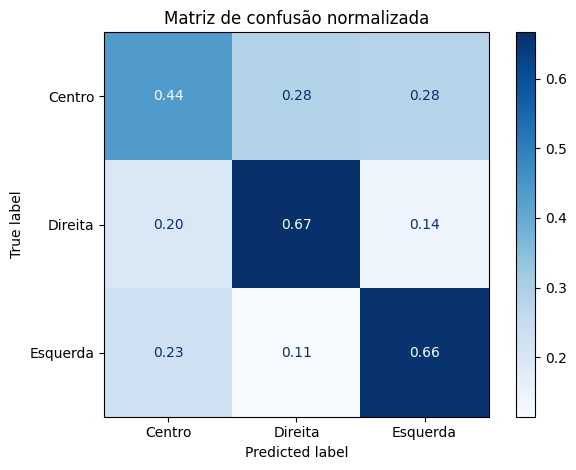

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', values_format=".2f", cmap='Blues', display_labels=final_model.classes_)
plt.title("Matriz de confusão normalizada")
plt.tight_layout()
plt.savefig(r'..\images\matriz_confusao_catboost.png')
plt.show()

A matriz de confusão revela que o modelo confunde Centro com Direita e Esquerda, mas os espectros políticos bem definidos (Esquerda e Direita) não se confundem muito entre si.

### **6.7. Variáveis mais importantes para o modelo**

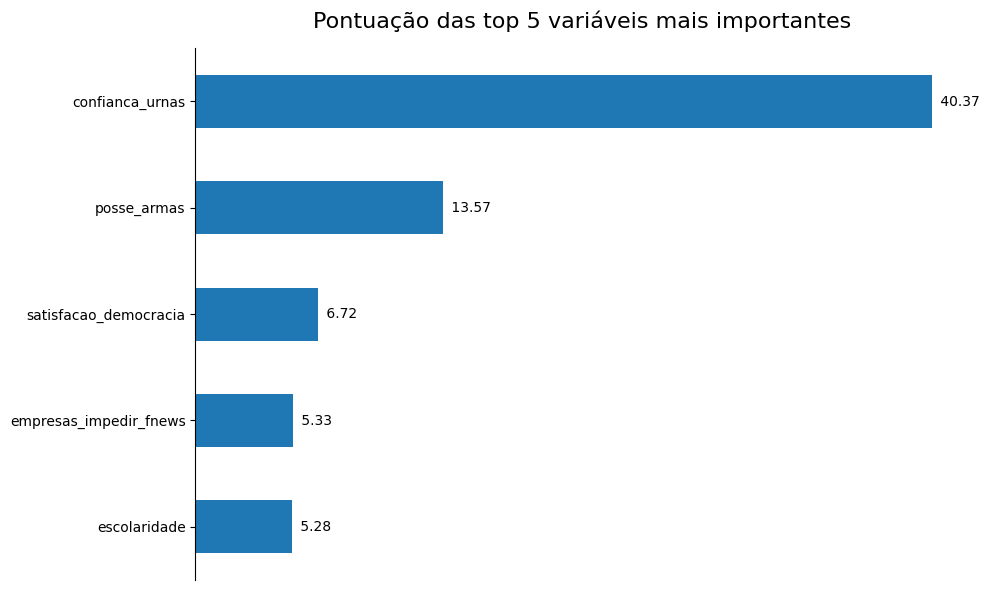

In [12]:
imp_df = final_model.get_feature_importance(prettified=True).sort_values('Importances', ascending=False).head(5)
ax = imp_df.plot(kind='barh', x='Feature Id', y='Importances', figsize=(10, 6), legend=False, color='#1f77b4')

ax.bar_label(ax.containers[0], fmt=' %.2f', padding=3)
ax.get_xaxis().set_visible(False)
ax.set_ylabel("")
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.title('Pontuação das top 5 variáveis mais importantes', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(r'..\images\feature_importance_catboost.png')
plt.show()

O gráfico revela que questões polêmicas são bastante relevantes para o modelo, sendo a opinião sobre confiança nas urnas eletrônicas a mais importante.

### **6.8. Conclusão**

O modelo consegue distinguir espectros políticos bem definidos (Direita e Esquerda), mas enfrenta dificuldades ao tentar classificar o posicionamento de Centro.

### **6.9. Salvando o modelo**

In [13]:
final_model.save_model("../models/catboost_posicionamento_politico.cbm")